# MTH3302 : Méthodes probabilistes et statistiques pour l'I.A.

Jonathan Jalbert<br/>
Professeur agrégé au Département de mathématiques et de génie industriel<br/>
Polytechnique Montréal<br/>


# TD3 - Régression linéaire

Ce TD concerne la régression linéaire (Chapitre 2 du cours). À la fin de ce TD, vous devriez être avoir été en mesure de :
- Tester l'importance de la régression
- Calculer les intervalles de confiance des coefficients de régression.
- Identifier les variables explicatives les plus importantes.


# Contexte : Tension artérielle des patients

Le jeu de données étudié dans ce TD concerne la prédiction de la tension artérielle (:BP) d'un patient mesurée en *mm* de mercure en fonction des 6 variables explicatives suivantes :

- x₁ : âge en années (:Age);
- x₂ : masse en *kg* (:Weight);
- x₃ : surface corporelle en *m²* (:BSA) ;
- x₄ : durée de l'hypertension en années (:Dur) ;
- x₅ : pouls basal en battements par minute (:Pulse) ;
- x₆ : niveau de stress de 0 à 100 (:Stress).

Le fichier *bloodpressure.csv* contient les tensions artérielles de 20 patients en plus des 6 variables explicatives.


In [1]:
# Chargement des librairies
using CSV, DataFrames, Distributions, Gadfly, Statistics, LinearAlgebra

In [2]:
data = CSV.read("bloodpressure.csv", DataFrame)
first(data,10)

Row,Pt,BP,Age,Weight,BSA,Dur,Pulse,Stress
,Int64,Int64,Int64,Float64,Float64,Float64,Int64,Int64
1,1,105,47,85.4,1.75,5.1,63,33
2,2,115,49,94.2,2.1,3.8,70,14
3,3,116,49,95.3,1.98,8.2,72,10
4,4,117,50,94.7,2.01,5.8,73,99
5,5,112,51,89.4,1.89,7.0,72,95
6,6,121,48,99.5,2.25,9.3,71,10
7,7,121,49,99.8,2.25,2.5,69,42
8,8,110,47,90.9,1.9,6.2,66,8
9,9,110,49,89.2,1.83,7.1,69,62


# Exercice 1

Dans cet exercice, on souhaite tester l'importance de la régression, c'est-à-dire vérifier si au moins une variable explicative possède un pouvoir prédictif significatif de la tension artérielle.


Pour répondre à cette question, l'importance de la régression sera testée.

In [3]:
# Variable d'intérêt
y = data.BP

# Taille d'échantillon
n = length(y)

# Matrice de structure
X = hcat(ones(n), Matrix(data[:,3:end]))

20×7 Matrix{Float64}:
 1.0  47.0   85.4  1.75   5.1  63.0  33.0
 1.0  49.0   94.2  2.1    3.8  70.0  14.0
 1.0  49.0   95.3  1.98   8.2  72.0  10.0
 1.0  50.0   94.7  2.01   5.8  73.0  99.0
 1.0  51.0   89.4  1.89   7.0  72.0  95.0
 1.0  48.0   99.5  2.25   9.3  71.0  10.0
 1.0  49.0   99.8  2.25   2.5  69.0  42.0
 1.0  47.0   90.9  1.9    6.2  66.0   8.0
 1.0  49.0   89.2  1.83   7.1  69.0  62.0
 1.0  48.0   92.7  2.07   5.6  64.0  35.0
 1.0  47.0   94.4  2.07   5.3  74.0  90.0
 1.0  49.0   94.1  1.98   5.6  71.0  21.0
 1.0  50.0   91.6  2.05  10.2  68.0  47.0
 1.0  45.0   87.1  1.92   5.6  67.0  80.0
 1.0  52.0  101.3  2.19  10.0  76.0  98.0
 1.0  46.0   94.5  1.98   7.4  69.0  95.0
 1.0  46.0   87.0  1.87   3.6  62.0  18.0
 1.0  46.0   94.5  1.9    4.3  70.0  12.0
 1.0  48.0   90.5  1.88   9.0  71.0  99.0
 1.0  56.0   95.7  2.09   7.0  75.0  99.0

## a) Calculez la variabilité totale SST

In [4]:
# Function to compute the total sum of square (SST)
function compute_sst(y::Vector{Int64})
    return sum((y .- mean(y)).^2)
end

SST = compute_sst(y)
println("SST = $(SST)")


SST = 560.0


In [5]:
# Vous devriez obtenir SST = 560

## b) Calculez la variabilité expliquée (SSR) et la variabilité résiduelle (SSE)

Pour tester l'importance de la régression, on utilise toutes les variables explicatives.

In [6]:
# Function to compute beta_cap_vector
function compute_beta_vector(X::Matrix{Float64}, y::Vector{Int64})
    # Using the decomposition X = QR, and β̂ = R_inv Q_transp y,
    # β̂  = (X'X)^(-1) X'y, where X' = X_traspose, can be obtained 
    # the alternative by the formula β̂ = X \ y.

    return X \ y
end


# Function to compute variability explained by regression (SSR)
function compute_ssr(X::Matrix{Float64}, y::Vector{Int64})
    # Compute beta_cap_vector.
    beta_cap_vector = compute_beta_vector(X, y)

    # Compute and the variability of y associated to regression
    y_cap_multiple_reg = X * beta_cap_vector
    return sum((y_cap_multiple_reg .- mean(y)).^2)
end

SSR = compute_ssr(X, y)

# Calculate SSE (residual variability or error variability)
SSE = SST - SSR

# Print the values of SSE and SSR
println("SSR = $(SSR)")
println("SSE = $(SSE)")

SSR = 557.8441422634095
SSE = 2.1558577365905194


In [7]:
# Vous devriez obtenir SSR = 557.8 et SSE = 2.16.

## c) Calculez la statistique observée permettant de tester l'importance de la régression

La statistique du test est égale à :

$$F = \frac{(n-p-1)}{p} \frac{SS_R}{SS_E}.$$

In [8]:
function compute_observed_stat(n::Int64, p::Int64, SSR::Float64, SSE::Float64)
    return ((n - p - 1) * SSR) / (p * SSE)
end

p = 6 # (The number of x_i variables has been given)
f_observed = compute_observed_stat(n, p, SSR, SSE)
println("F = $(f_observed)")

F = 560.641032904556


In [9]:
# Vous devriez obtenir Fₒ = 560.6.

## d) Illustrez la distribution de la statistique de test lorsque l'hypothèse nulle est vraie.

Lorsque l'hypothèse nulle est vraie, on a que 

$$F \sim \mathcal{F}isher(p, n-p-1).$$

**Suggestion :** Utilisez l'objet *FDist* de la librairie *Distributions.jl* pour appliquer la méthode `pdf()` donnant la densité. 

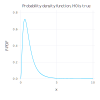

In [10]:
# Create the F-distribution with p and (n - p - 1) degrees 
# of freedom.
f_distribution = FDist(p, (n - p - 1))

# Generate x-values for the probability density function.
x_vals = range(start=0, stop=10, length=10000)

# Compute the probability density function
f_pdf_vals = pdf.(f_distribution, x_vals)

# Combine x_vals and f_pdf_vals into dataframe-like 
# structure (df) for Gadfly.
df = (collect(x_vals), collect(f_pdf_vals))

# Parameter1= width; Parameter2 = height.
set_default_plot_size(10cm, 10cm)

# Plot the F-distribution PDF
plot1 = Gadfly.plot(
    df, 
    x = x_vals, 
    y = f_pdf_vals,
    Geom.line,
    Guide.xlabel("x"),
    Guide.ylabel("F-PDF"),
    Guide.title("Probability density function, H0 is true")
    )


## e) Calculez la région critique pour le rejet de l'hypothèse nulle

Utilisez le risque α = 5%

**Suggestion :** Utilisez la méthode `quantile()` pour identifier le point de la région critique. 

In [11]:
function compute_critical_val_f_dist(f_dist::Distribution, alpha::Float64)
    return quantile(f_dist, 1 - alpha)
end

alpha = 0.05 # (given)
f_critical_val = compute_critical_val_f_dist(f_distribution, alpha)
print("Seuil Critique pour le rejet de l'hypothèse nulle : $(f_critical_val)")

Seuil Critique pour le rejet de l'hypothèse nulle : 2.9152692387027535

In [12]:
# Vous devriez obtenir seuil = 2.915

## f) Quelle est la décision du test

Décidez si vous rejetez ou non l'hypothèse nulle.

### Réponse ( 1f )
Rejeter H0, car la statistique observée du test (F = f_observed = 560.6) est supérieure au seuil critique pour le rejet de l'hypothèse nulle (f_critical = 2.915), pour alpha = 0.05 (quantile d'ordre 95% de la loi de fisher). 

In [13]:
# Vous devriez rejeter l'hypothèse nulle.

## g) Calculez le seuil observé du test (la valeur-p)

La valeur-p est la probabilité d'observer une statistique plus extrême que celle obtenue.

**Suggestion :** Utilisez la méthode `cdf()`. 

In [14]:
function compute_p_value_f_dist(f_stat::Real, f_dist::Distribution, tail::Symbol)
    # Validate the inputs
    if !(tail in (:right, :left, :two))
        error("Tail must be right, left, or two.")
    elseif f_stat < 0
        error("F-statistic should be positive.")
    end

    # Generate the CDF values.
    cdf_value = cdf(f_dist, f_stat)

    # Based on the tail type, determine the p-value.
    if tail == :right
        return 1 - cdf_value
    elseif tail ==:left
        return cdf_value
    else
        return (2 * min(1 - cdf_value, cdf_value))
    end
end

p_value_f_dist = compute_p_value_f_dist(f_observed, f_distribution, :right)
println("The p-value for the F-distribution is : $(p_value_f_dist)")

The p-value for the F-distribution is : 6.439293542825908e-15


In [15]:
# Vous devriez obtenir valeurp = 6.44e-15

# Exercice 2

## a) Estimez la variance de l'erreur.

En utilisant toutes les variables explicatives.

In [16]:
# Function to compute residual variance (variance of error terme). 
function compute_error_var(X::Matrix{Float64}, y::Vector{Int64})
    # Compute beta_cap_vector.
    beta_cap_vector = compute_beta_vector(X, y)

    # Compute the residuals.
    residuals = y - (X * beta_cap_vector)

    # Extract the number of observations from the matrix.
    n = size(X, 1)

    # Extract the number of predictors from the matrix.
    # Remove "1" because the matrix contains the column patient, 
    # which is not considered (not an independent variable considered).
    p = size(X, 2) - 1   

    # Compute and return the error_variance.
    return (1 / (n - p - 1)) * sum(residuals.^2)
end

error_variance = compute_error_var(X, y)
println("Residual variance = $(error_variance)")

Residual variance = 0.16583521050683192


In [17]:
# Vous devriez obtenir σ̂² = 0.1658

## b) Calculez les intervalles de confiance à 95 % pour β

In [46]:
# Function to compute the f-confidence interval (CI) for beta_cap_vector.
function compute_f_confidence_intervals(beta_cap::Vector, cov_beta::Matrix, df_resid::Int, alpha=0.05)
    p = length(beta_cap)
    confidence_intervals = Vector{Tuple{Float64, Float64}}(undef, p)

    for i in 1:p
        standard_error = sqrt(cov_beta[i, i])
        f_critical_val = quantile(FDist(1, df_resid), 1 - alpha)
        margin = sqrt(f_critical_val) * standard_error
        confidence_intervals[i] = (beta_cap[i] - margin, beta_cap[i] + margin)
    end
    return confidence_intervals
end

# Compute the beta_cap_vector (first function parameter).
beta_cap_vector = compute_beta_vector(X, y)

# Compute the variance-covariance matrix of beta_cap_vector
# (second function parameter).
var_cov_beta = error_variance * inv(X' * X)

# Compute the degrees of freedom of the residues
# (third function parameter).
df_residues = n - p - 1

# Compute the f-confidence intervals using the function call.
confidence_intervals = compute_f_confidence_intervals(beta_cap_vector, var_cov_beta, df_residues, 0.05)

# Display the f-confidence intervals.
display(confidence_intervals)

# Afficher les résultats.
for i in eachindex(beta_cap_vector)
    if i == length(beta_cap_vector)
        print("β_$(i-1) ∈ [$(confidence_intervals[i][1]), $((confidence_intervals[i][2]))]")
    else
        print("β_$(i-1) ∈ [$(confidence_intervals[i][1]), $((confidence_intervals[i][2]))], ")
    end
end

7-element Vector{Tuple{Float64, Float64}}:
 (-18.39378228657295, -7.3471697567656715)
 (0.5960925680398511, 0.8104262206744218)
 (0.833582246426293, 1.106257309929991)
 (0.3627826017506761, 7.190199405154763)
 (-0.03626843603334726, 0.17303451669696235)
 (-0.1959791088185025, 0.027009735144252242)
 (-0.0018003258106534916, 0.012943326183328926)

β_0 ∈ [-18.39378228657295, -7.3471697567656715], β_1 ∈ [0.5960925680398511, 0.8104262206744218], β_2 ∈ [0.833582246426293, 1.106257309929991], β_3 ∈ [0.3627826017506761, 7.190199405154763], β_4 ∈ [-0.03626843603334726, 0.17303451669696235], β_5 ∈ [-0.1959791088185025, 0.027009735144252242], β_6 ∈ [-0.0018003258106534916, 0.012943326183328926]

In [ ]:
# Vous devriez obtenir β₁ ∈ [0.596 , 0.81], etc.

## c) Quelles variables semblent non significatives ?

## Réponse ( 2c )
En utilisant les intervalles de confiance comme critère, pour une 'distribution-F', une variable est significative si son intervalle de confiance ne contient pas zéro. Autrement (si l'intervalle de confiance d'une variable contient zéro), alors cette variable n'est pas significative.
Les trois variables qui semblent donc non-significatives sont celles qui ont des intervalles de confiance qui contiennent zéro, à savoir : 'Dur', 'Pulse', et 'Stress'.

# Exercice 3

Pour identifier la variable explicative la plus importante, on peut estimer tous les modèles de régression linéaire simple et comparer les coefficients de détermination. Le modèle ayant le coefficient de détermination le plus élevé correspond à la variable explicative la plus importante.

Une autre façon de faire pour ordonner l'importance des variables explicatives consiste à comparer le ratio signal sur bruit des coefficients de régression. Le score-Z permet de calculer ce ratio :

$$ \operatorname{Z-score}_j  = \frac{β̂ⱼ}{\sqrt{σ̂² \times v_{j+1}}}.$$

La variable la plus importante est celle qui possède le plus grand score-*Z* en valeur absolue.

Calculez les score-Z de chacune des variables explicatives pour déterminer celle qui explique le mieux la tension artérielle.

In [88]:
# Function to compute z-values
function compute_z_values(beta_cap::Vector, var_cov_beta::Matrix)
    # Compute the standard errors.
    standard_errors = sqrt.(diag(var_cov_beta))
    # Return the z-scores.
    return abs.(beta_cap_vector ./ standard_errors)
end

# Compute beta_cap_vector.
beta_cap_vector = compute_beta_vector(X, y)

# Compute the variance-covariance matrix of beta_cap_vector
var_cov_beta = error_variance * inv(X' * X)

# Compute the z-score using the function.
z_scores = compute_z_values(beta_cap_vector, var_cov_beta)

# Extract the maximum value from the column corresponding to this
# maximum value.

max_value, max_index = findmax(z_scores)

# Extract the name of the column corresponding to this
# maximum value
column_names = names(data)
# One is added because of the column 'Pt', which is not an independent 
# explanatory variable and which appears before all independent variables.
column_name = column_names[max_index + 1] 
println("La variable (colonne) '$column_name' est la variable explicative la plus importante avec un score-z de $max_value")


La variable (colonne) 'Weight' est la variable explicative la plus importante avec un score-z de 15.369093610065189


In [ ]:
# Vous devriez obtenir que le poids est la variable la plus importante avec un score-Z de 15.4.

# Exercice 4

Encore une autre façon pour ordonner l'importance des variables explicatives consiste à comparer les estimations des coefficients de régression lorsque les variables explicatives et la variable d'intérêt sont d'abord standardisées.

Lorsque toutes les variables explicatives sont standardisées, elles sont donc sur la même échelle et les coefficients de régression peuvent être directement comparés. En l'occurrence, un coefficient plus grand implique un effet plus grand.

**Remarque :** Lorsque toutes les variables sont standardisées, l'ordonnée à l'origine n'est plus nécessaire. Pour le comprendre, regarder l'expression de β̂₀ dans la régression linéaire simple.

Calculez les coefficients de régression en utilisant les variables standardisées. Identifiez la variable explicative la plus importante.

In [ ]:
# Vous devriez obtenir que le poids est la variable la plus importante avec β̂₂ = 0.767.